In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("INFO")

[2025年04月02日 16时45分21秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

In [2]:
fadata = cfe.data.read_pancrease(n_obs=500)
fadata

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'milestone_color_dict', 'milestone_colors', 'milestone_color_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

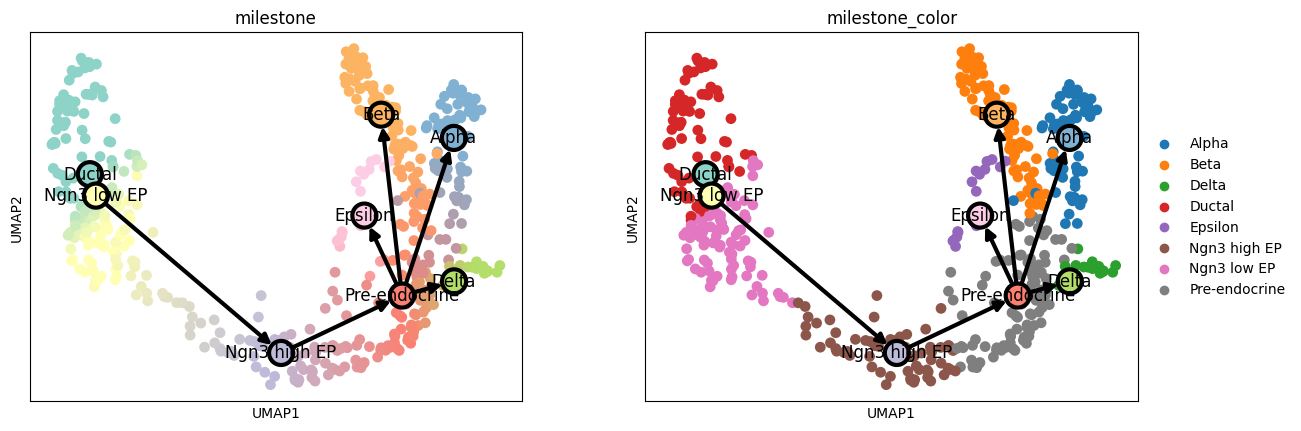

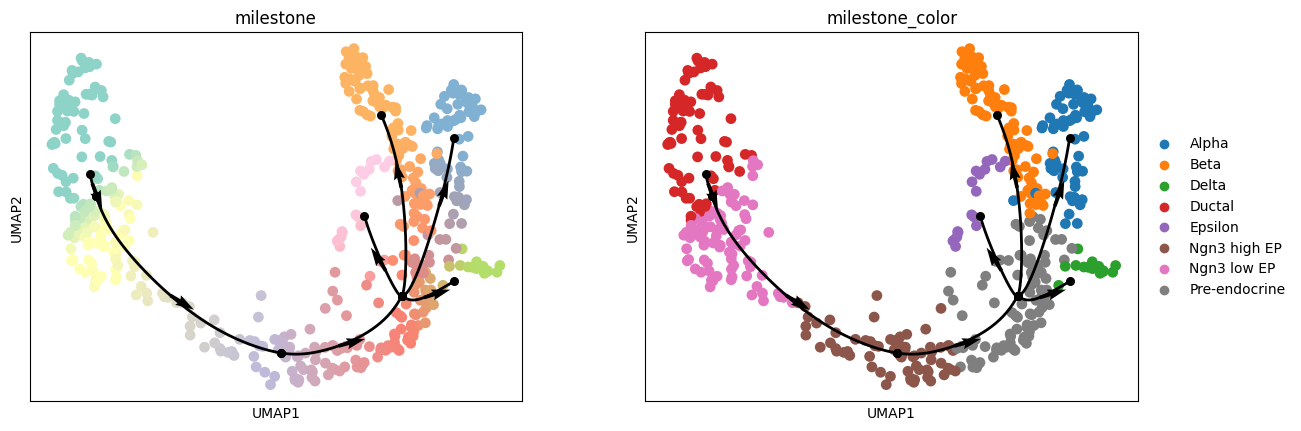

In [3]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

basis = "umap"
cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=False)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=True)
fadata

[2025年04月02日 15时43分23秒] INFO     find wrapper type: directed                                                 


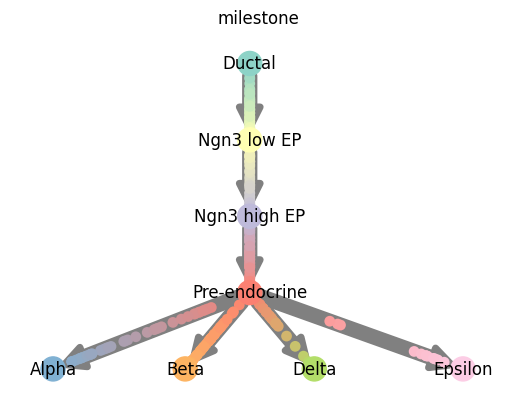

In [4]:
cfe.plot.plot_wrapper(fadata)

[2025年04月02日 15时43分25秒] INFO     Loaded function: <function cf_scvelo at 0x7854abb6b400> from                
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_scvelo.py                                                             
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x78555c91e950>                                                                   
Filtered out 24737 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:03) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (

  0%|          | 0/500 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:00) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


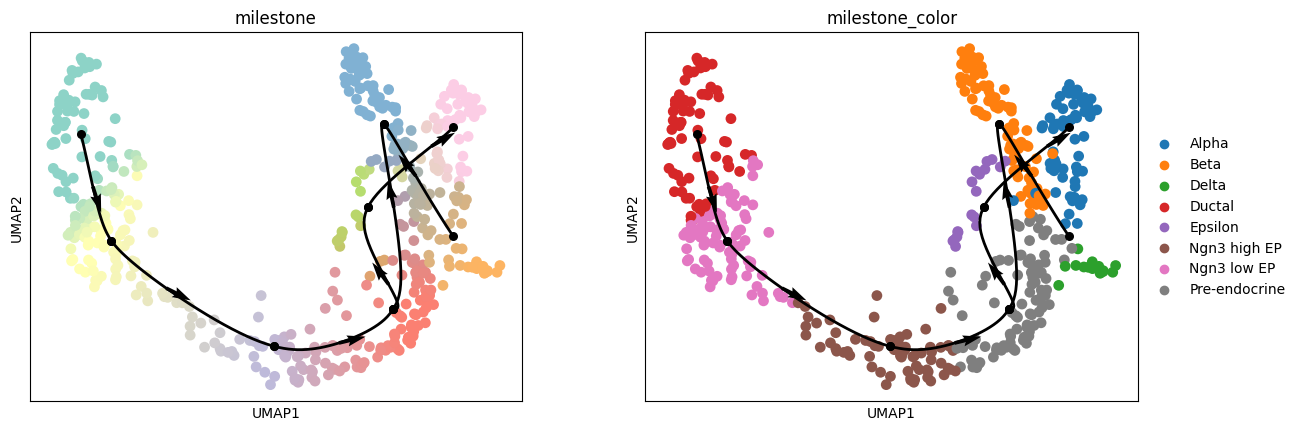

In [5]:
prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


method_name_list = ["scvelo"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)

    method.infer_trajectory(fadata)

    cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)

额外绘制wrapper

[2025年04月02日 15时43分32秒] INFO     find wrapper type: velocity                                                 
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


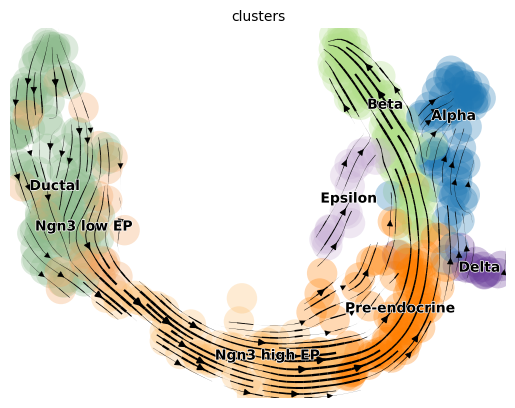

In [6]:
cfe.plot.plot_wrapper(fadata)